In [52]:
import sys
sys.path.append('../')
from core import LADTransferTreeBoost, LSTransferTreeBoost, MTransferTreeBoost
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from utils import *  #only needed for xgboost
import xgboost as xgb
from baselines import *

In [53]:
predictor_columns = ['zq5', 'zq10', 'zq15', 'zq20', 'zq25', 'zq30', 'zq35', 
                     'zq40', 'zq45', 'zq50', 'zq55', 'zq60', 'zq65', 'zq70',
                     'zq75', 'zq80', 'zq85', 'zq90', 'zq95',
                     'pzabove2', 'pzabovezmean', 'zmax']
target_column = 'Hgv'

In [54]:
data_source = pd.read_csv('datasets/rs_sweden.csv', index_col = [0])
data_target = pd.read_csv('datasets/rs_lettland.csv', index_col = [0])
print(f'source dataset size: {len(data_source)}, target dataset size: {len(data_target)}')

data_temp, data_test = train_test_split(data_target, test_size=0.9, random_state=700)
data_train, data_val = train_test_split(data_temp, test_size=0.1, random_state=1)

print(f'train (target) dataset size: {len(data_train)}, val (target) dataset size: {len(data_val)}, test (target) dataset size: {len(data_test)}')


source dataset size: 8412, target dataset size: 1900
train (target) dataset size: 171, val (target) dataset size: 19, test (target) dataset size: 1710


In [55]:
X_source_train = np.array(data_source[predictor_columns])
y_source_train = np.array(data_source[target_column]) #change this to "Dgv" to use diameter as source label!

#Specific train and test set
X_target_train = np.array(data_train[predictor_columns])
y_target_train = np.array(data_train[target_column])

X_target_val = np.array(data_val[predictor_columns])
y_target_val = np.array(data_val[target_column])

X_target_test = np.array(data_test[predictor_columns])
y_target_test = np.array(data_test[target_column])

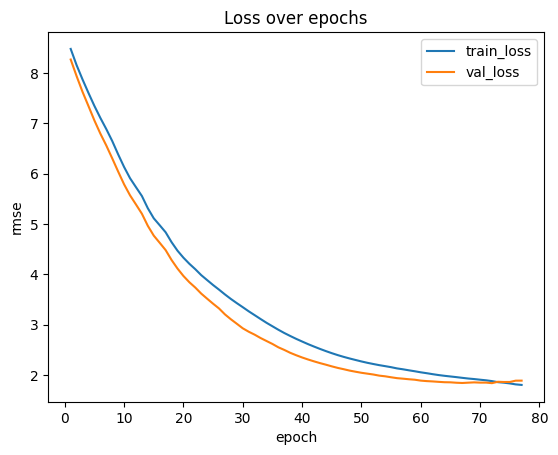

12.548488901856784


In [56]:
fiter = MTransferTreeBoost(epochs=300, source_tree_size=2, target_tree_size=2, k = 0.01)
fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train, val_x=X_target_val, val_y=y_target_val, early_stopping_rounds=5, show_curves = True)
rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
val_rmse = fiter.evaluate(X_target_val, y_target_val, metric = 'rmse')
mae = fiter.evaluate(X_target_test, y_target_test, metric = 'mae')
val_mae = fiter.evaluate(X_target_val, y_target_val, metric = 'mae')

print((rmse / np.mean(y_target_test))*100)

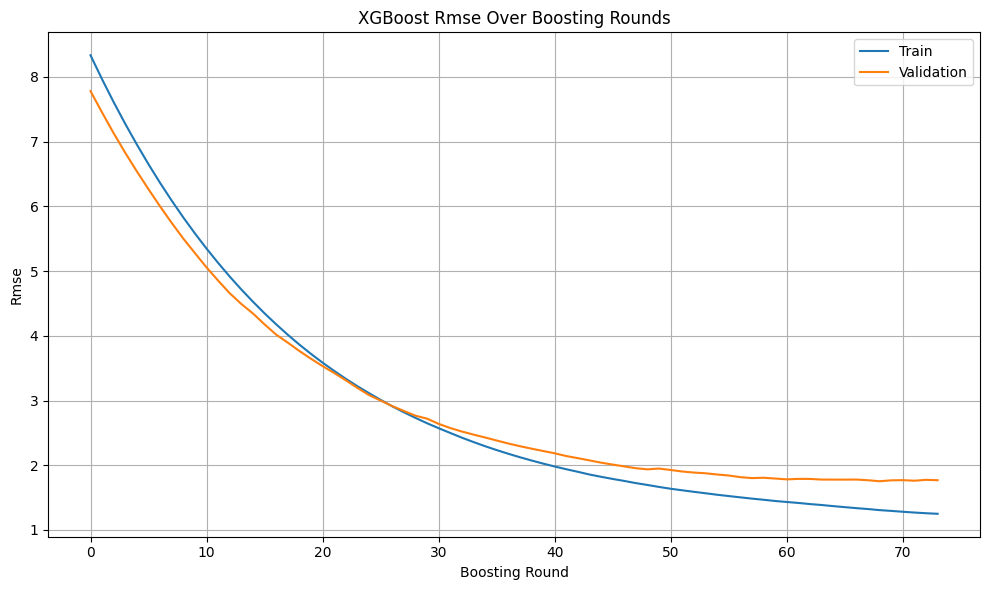

13.021086961299092


In [57]:
params = {
    'objective': 'reg:squarederror',  # Regression with squared error
    'max_depth': 3,                   # Maximum depth of a tree
    'eta': 0.05,                       # Learning rate
    'eval_metric': 'rmse',           # RMSE as evaluation metric
    }
        
bst = train_xgboost(X_target_train, y_target_train, X_target_val, y_target_val, boosting_rounds=300, params=params, early_stopping_rounds=5, show_curve=True)
preds = test_xgboost(X_target_test, bst)
val_preds = test_xgboost(X_target_val, bst)
val_rmse = compute_rmse(val_preds, y_target_val)
val_mae = compute_mae(val_preds, y_target_val)
rmse = compute_rmse(preds, y_target_test)
mae = compute_mae(preds, y_target_test)

print((rmse / np.mean(y_target_test))*100)

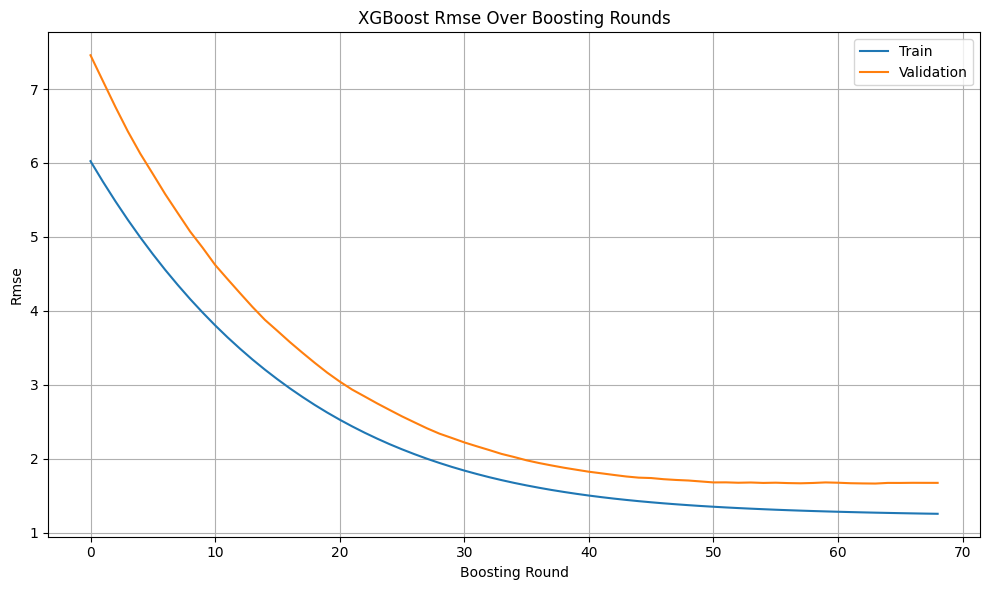

12.784464338959332


In [58]:
#additional source/target dummy sets for naive xgboost
ones = np.ones((len(X_target_train), 1))
X_target_train_with_dummy = np.hstack((X_target_train.copy(), ones))
ones = np.ones((len(X_target_val), 1))
X_target_val_with_dummy = np.hstack((X_target_val.copy(), ones))
ones = np.ones((len(X_target_test), 1))
X_target_test_with_dummy= np.hstack((X_target_test.copy(), ones))

zeros = np.zeros((len(X_source_train), 1))
X_source_train_with_dummy = np.hstack((X_source_train.copy(), zeros))

X_comb = np.concatenate((X_target_train_with_dummy, X_source_train_with_dummy)) 
y_comb = np.concatenate((y_target_train, y_source_train))       
bst = train_xgboost(X_comb, y_comb, X_target_val_with_dummy, y_target_val, boosting_rounds=100, params=params, early_stopping_rounds=5, show_curve=True)
preds = test_xgboost(X_target_test_with_dummy, bst)
val_preds = test_xgboost(X_target_val_with_dummy, bst)
val_rmse = compute_rmse(val_preds, y_target_val)
val_mae = compute_mae(val_preds, y_target_val)
rmse = compute_rmse(preds, y_target_test)
mae = compute_mae(preds, y_target_test)
print((rmse / np.mean(y_target_test))*100)

In [59]:
import warnings
warnings.filterwarnings('ignore')
from adapt.instance_based import TrAdaBoostR2, TwoStageTrAdaBoostR2
from sklearn.metrics import mean_squared_error, mean_absolute_error
from m5py import M5Prime

from lineartree import LinearTreeRegressor
from sklearn.linear_model import LinearRegression

base_estimator = M5Prime()
model = TrAdaBoostR2(base_estimator,
                        n_estimators=30,
                        lr=1)
model.fit(X_source_train, y_source_train,
            X_target_train, y_target_train)
preds = model.predict(X_target_test)
val_preds = model.predict(X_target_val)
val_rmse = np.sqrt(
    mean_squared_error(val_preds, y_target_val))
val_mae = mean_absolute_error(val_preds, y_target_val)
rmse = np.sqrt(mean_squared_error(
    preds, y_target_test))
mae = mean_absolute_error(preds, y_target_test)
print((rmse / np.mean(y_target_test))*100)

KeyboardInterrupt: 

In [ ]:

# base_estimator = LinearTreeRegressor(
#     base_estimator=LinearRegression(),
#     max_depth=5,
#     min_samples_leaf=3)
base_estimator = M5Prime()
model = TwoStageTrAdaBoostR2(base_estimator,
                        n_estimators=30,
                        n_estimators_fs=30,
                        cv=10,
                        lr=1)
model.fit(X_source_train, y_source_train,
            X_target_train, y_target_train)
preds = model.predict(X_target_test)
val_preds = model.predict(X_target_val)
val_rmse = np.sqrt(
    mean_squared_error(val_preds, y_target_val))
val_mae = mean_absolute_error(val_preds, y_target_val)
rmse = np.sqrt(mean_squared_error(
    preds, y_target_test))
mae = mean_absolute_error(preds, y_target_test)
print((rmse / np.mean(y_target_test))*100)

Iteration 0 - Cross-validation score: 2.4134 (0.7486)


KeyboardInterrupt: 

In [ ]:
df = pd.DataFrame(columns = ['seed', 'method', 'rmse'])

for seed in range(89,90):
    data_source = pd.read_csv('datasets/rs_sweden.csv', index_col = [0])[0:400]
    data_target = pd.read_csv('datasets/rs_lettland.csv', index_col = [0])[0:300]
    print(f'source dataset size: {len(data_source)}, target dataset size: {len(data_target)}')

    data_temp, data_test = train_test_split(data_target, test_size=0.1, random_state=seed)
    data_train, data_val = train_test_split(data_temp, test_size=0.1, random_state=seed)

    X_source_train = np.array(data_source[predictor_columns])
    y_source_train = np.array(data_source[target_column]) #change this to "Dgv" to use diameter as source label!

    #Specific train and test set
    X_target_train = np.array(data_train[predictor_columns])
    y_target_train = np.array(data_train[target_column])

    X_target_val = np.array(data_val[predictor_columns])
    y_target_val = np.array(data_val[target_column])

    X_target_test = np.array(data_test[predictor_columns])
    y_target_test = np.array(data_test[target_column])

    fiter = MTransferTreeBoost()
    fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train, val_x=X_target_val, val_y=y_target_val, early_stopping_rounds=5, show_curves = False)
    rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
    val_rmse = fiter.evaluate(X_target_val, y_target_val, metric = 'rmse')
    mae = fiter.evaluate(X_target_test, y_target_test, metric = 'mae')
    val_mae = fiter.evaluate(X_target_val, y_target_val, metric = 'mae')

    df.loc[len(df)] = [seed, 'MTransferTreeBoost', rmse]

    params = {
    'objective': 'reg:squarederror',  # Regression with squared error
    'max_depth': 2,                   # Maximum depth of a tree
    'eta': 0.1,                       # Learning rate
    'eval_metric': 'rmse',           # RMSE as evaluation metric
    }
        
    bst = train_xgboost(X_target_train, y_target_train, X_target_val, y_target_val, boosting_rounds=300, params=params, early_stopping_rounds=5, show_curve=False)
    preds = test_xgboost(X_target_test, bst)
    val_preds = test_xgboost(X_target_val, bst)
    val_rmse = compute_rmse(val_preds, y_target_val)
    val_mae = compute_mae(val_preds, y_target_val)
    rmse = compute_rmse(preds, y_target_test)
    mae = compute_mae(preds, y_target_test)

    df.loc[len(df)] = [seed, 'XGBoost', rmse]

    #additional source/target dummy sets for naive xgboost
    ones = np.ones((len(X_target_train), 1))
    X_target_train_with_dummy = np.hstack((X_target_train.copy(), ones))
    ones = np.ones((len(X_target_val), 1))
    X_target_val_with_dummy = np.hstack((X_target_val.copy(), ones))
    ones = np.ones((len(X_target_test), 1))
    X_target_test_with_dummy= np.hstack((X_target_test.copy(), ones))

    zeros = np.zeros((len(X_source_train), 1))
    X_source_train_with_dummy = np.hstack((X_source_train.copy(), zeros))

    X_comb = np.concatenate((X_target_train_with_dummy, X_source_train_with_dummy)) 
    y_comb = np.concatenate((y_target_train, y_source_train))       
    bst = train_xgboost(X_comb, y_comb, X_target_val_with_dummy, y_target_val, boosting_rounds=300, params=params, early_stopping_rounds=5, show_curve=False)
    preds = test_xgboost(X_target_test_with_dummy, bst)
    val_preds = test_xgboost(X_target_val_with_dummy, bst)
    val_rmse = compute_rmse(val_preds, y_target_val)
    val_mae = compute_mae(val_preds, y_target_val)
    rmse = compute_rmse(preds, y_target_test)
    mae = compute_mae(preds, y_target_test)

    df.loc[len(df)] = [seed, 'Naïve XGBoost', rmse]


    base_estimator = M5Prime()
    model = TrAdaBoostR2(base_estimator,
                            n_estimators=30,
                            lr=1, verbose = False)
    model.fit(X_source_train, y_source_train,
                X_target_train, y_target_train)
    preds = model.predict(X_target_test)
    val_preds = model.predict(X_target_val)
    val_rmse = np.sqrt(
        mean_squared_error(val_preds, y_target_val))
    val_mae = mean_absolute_error(val_preds, y_target_val)
    rmse = np.sqrt(mean_squared_error(
        preds, y_target_test))
    mae = mean_absolute_error(preds, y_target_test)

    df.loc[len(df)] = [seed, 'TrAdaBoost.R2', rmse]

    base_estimator = M5Prime()
    model = TwoStageTrAdaBoostR2(base_estimator,
                            n_estimators=30,
                            n_estimators_fs=30,
                            cv=10,
                            lr=1)
    model.fit(X_source_train, y_source_train,
                X_target_train, y_target_train)
    preds = model.predict(X_target_test)
    val_preds = model.predict(X_target_val)
    val_rmse = np.sqrt(
        mean_squared_error(val_preds, y_target_val))
    val_mae = mean_absolute_error(val_preds, y_target_val)
    rmse = np.sqrt(mean_squared_error(
        preds, y_target_test))
    mae = mean_absolute_error(preds, y_target_test)
    df.loc[len(df)] = [seed, 'two-stage TrAdaBoost.R2', rmse]

source dataset size: 400, target dataset size: 300
Iteration 0 - Cross-validation score: 1.8599 (0.3320)
Iteration 1 - Cross-validation score: 1.8845 (0.4104)
Iteration 2 - Cross-validation score: 1.7990 (0.3074)
Iteration 3 - Cross-validation score: 1.7876 (0.2735)
Iteration 4 - Cross-validation score: 1.8212 (0.2992)
Iteration 5 - Cross-validation score: 1.8456 (0.3547)
Iteration 6 - Cross-validation score: 1.9099 (0.6899)
Iteration 7 - Cross-validation score: 1.9100 (0.3189)
Iteration 8 - Cross-validation score: 1.7363 (0.2850)
Iteration 9 - Cross-validation score: 1.7827 (0.3444)
Iteration 10 - Cross-validation score: 1.7649 (0.3293)
Iteration 11 - Cross-validation score: 1.7894 (0.3585)
Iteration 12 - Cross-validation score: 1.7214 (0.3239)
Iteration 13 - Cross-validation score: 1.7677 (0.3526)
Iteration 14 - Cross-validation score: 1.7005 (0.3616)
Iteration 15 - Cross-validation score: 1.7857 (0.3705)
Iteration 16 - Cross-validation score: 1.7568 (0.3549)
Iteration 17 - Cross-val

<Axes: xlabel='method', ylabel='rmse'>

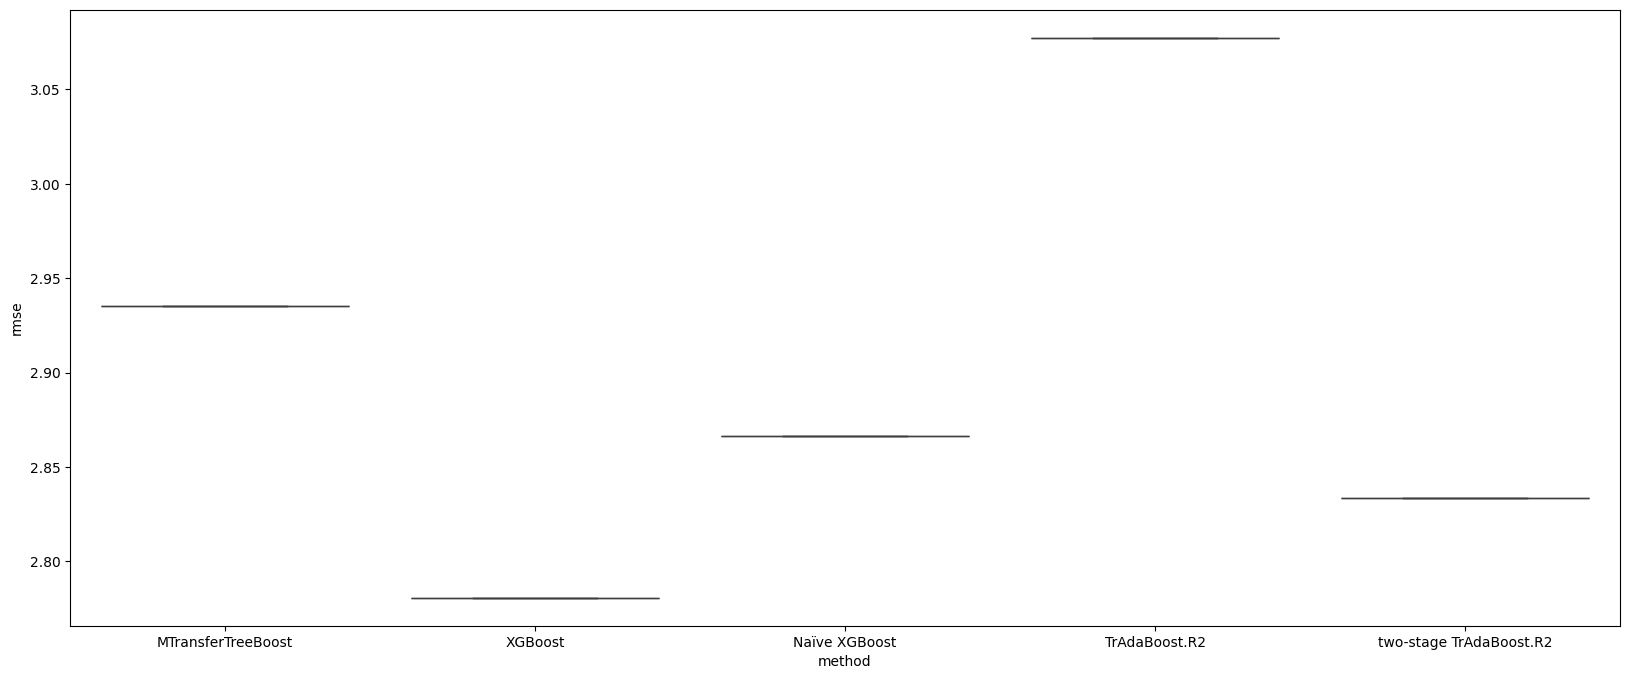

In [ ]:
plt.figure(figsize = (20, 8))
import seaborn as sns
sns.boxplot(data = df, x = 'method', y = 'rmse')

